# LTLf synthesis with unobservable variables

In [1]:
import spot
spot.setup(show_default='.A')

The following specification states that assuming `u` alternate between on and off (but we do not know its initial value), we eventually want that `o=u`.   This is realizable, for instance by a controller that continuously assign the same value to o.

In [2]:
f = 'G((!u | X!u) & (u | Xu)) -> X[!]F(u <-> o)'
out = ['o']
unobs = ['u']

Here is the automaton for `f` as an MTDFA, or as a DFA.

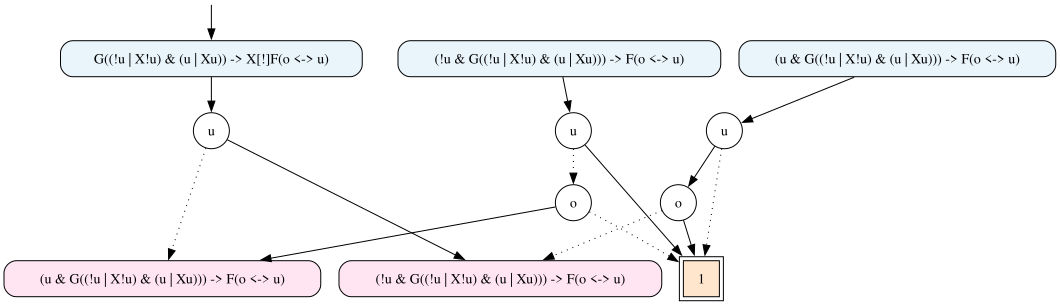

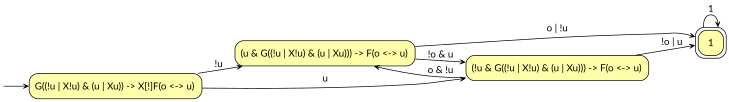

In [3]:
a = spot.ltlf_to_mtdfa(f); display(a); display(a.as_twa(True))

Here is the game generated for synthesis.  By comparing the labels of the states, we can see how `u` was quantified universally.

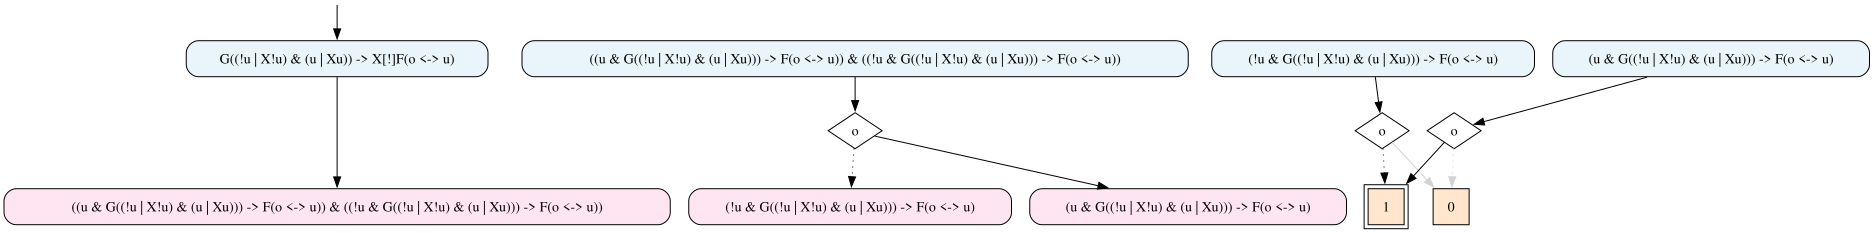

In [4]:
spot.ltlf_to_mtdfa_for_synthesis(f, out, unobs,
                                 spot.state_refine)  # slight simplifications, but no solving

Now, the solved version:

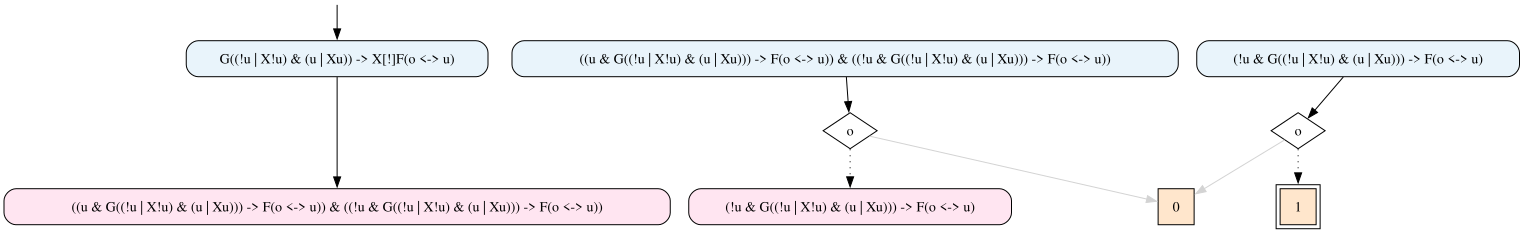

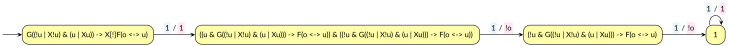

In [5]:
strat = spot.ltlf_to_mtdfa_for_synthesis(f, out, unobs)
display(strat)
display(spot.mtdfa_strategy_to_mealy(strat))